In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import h5py
from tqdm import tqdm

from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb

import sys
sys.path.append('../../../src/utils/')
sys.path.append('../../../src/preprocessing/')
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid, viz_h5_structure
from rotation_filter import RotateConv2d

In [2]:
conv = RotateConv2d(in_channels=3, out_channels=12, kernel_size=3, keep_original=False)
input = torch.randn(2, 3, 28, 28)
output = conv(input)
print(output.shape)

torch.Size([2, 12, 28, 28])


In [4]:
device = torch.device('cuda:9')
filter = RotateConv2d(in_channels=3, out_channels=12, kernel_size=3).to(device)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


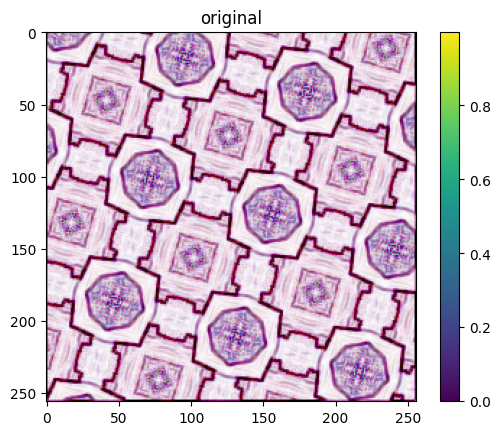

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


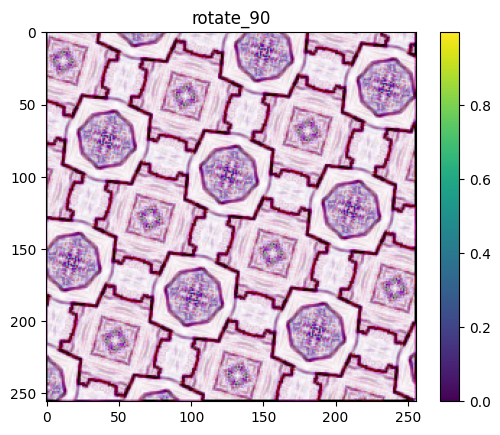

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


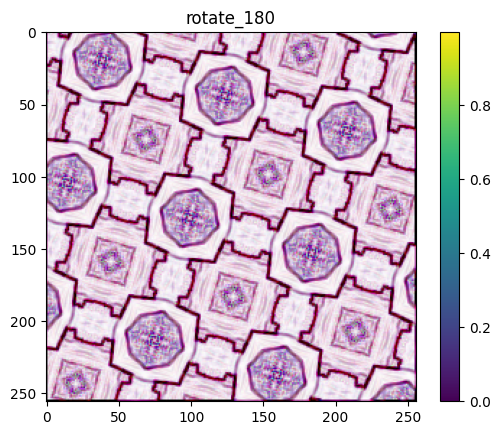

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


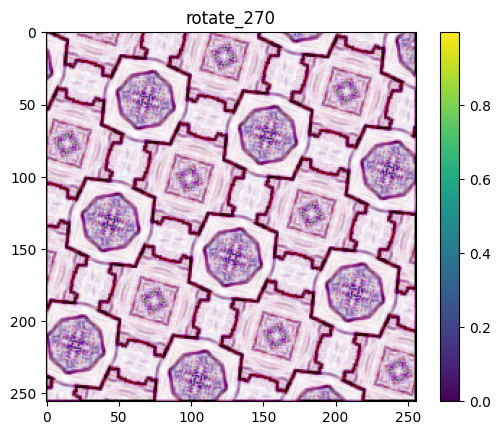

In [7]:
# test case 

import torch
import torchvision.transforms as transforms
from PIL import Image

# Load a sample image (e.g., a square)
with h5py.File('../../../datasets/imagenet_v4_rot_10m_train_unchunked.h5', 'r') as h5:
    image = h5['train']['data'][0]
# Define transformations for different symmetry operations 
   
transformations = {
    'original': transforms.ToTensor(),
    'rotate_90': transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.rot90(1, [1, 2]))]),
    'rotate_180': transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.rot90(2, [1, 2]))]),
    'rotate_270': transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.rot90(3, [1, 2]))]),
}

# Process the image with each transformation and pass through the RotateConv2d layer
rotate_conv_layer = RotateConv2d(in_channels=3, out_channels=3, kernel_size=3, symmetries=[4])

for name, transform in transformations.items():
    transformed_image = transform(image)
    output = rotate_conv_layer(transformed_image.unsqueeze(0))  # Add batch dimension

    transformed_image = output.permute(0, 2, 3, 1).detach().cpu().squeeze().numpy()
    plt.imshow(transformed_image)
    plt.colorbar()
    plt.title(name)
    plt.show()